In [1]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()

In [19]:
bins =20
left =0
right =7

steps = (right-left)/bins

fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["p"].clip(0, 7.5), bins=100, histtype="step", density=True)
ax2.set_xlabel("Momentum (GeV/c)"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 7.5, 10))
ax2.set_title("Momentum")
fig.tight_layout()
fig.savefig("figures/Momentum.png", dpi=150)
plt.close(fig)

fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(df["theta"].clip(0, 44), bins=100, histtype="step", density=True)
ax2.set_xlabel("Theta"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 44, 10))
ax2.set_title("Theta")
fig.tight_layout()
plt.show
fig.savefig("figures/theta.png", dpi=150)
plt.close(fig)

In [3]:
p=left #computes efficiancies
vals =[]
errs=[]
for i in range(bins):
    pCut = matched[((matched["p"]>=p)&(matched["p"] < p+steps))]
    a= ((pCut["mc_matching_pid"]==321) & (pCut["pid"]==321)).sum()
    b= (pCut["mc_matching_pid"]==321).sum()
    r=0
    rErr=99
    if b!=0:
        r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
    errs.append(rErr)
    vals.append(r)
    p = steps+p


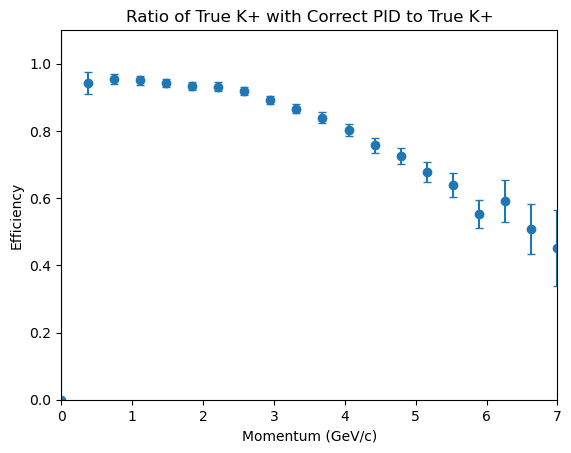

In [4]:


fig, ax = plt.subplots()

x = np.linspace(left, right, len(vals))

ax.errorbar(
    x,
    vals,
    yerr=errs,
    fmt='o',
    capsize=3
)
ax.set_ylim(0, 1.1)
ax.set_xlim(left, right)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Efficiency")
ax.set_title("Ratio of True K+ with Correct PID to True K+")
fig.savefig("figures/efficiencyK.png", dpi=150)
plt.show()



In [5]:
p=left   #computes Purity
vals =[]
errs=[]
for i in range(bins):
    pCut = matched[((matched["p"]>=p)&(matched["p"] < p+steps))]
    a= ((pCut["mc_matching_pid"]==321) & (pCut["pid"]==321)).sum()
    b= (pCut["pid"]==321).sum()
    r=0
    rErr=99
    if b!=0:
        r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
    errs.append(rErr)
    vals.append(r)
    p = steps+p

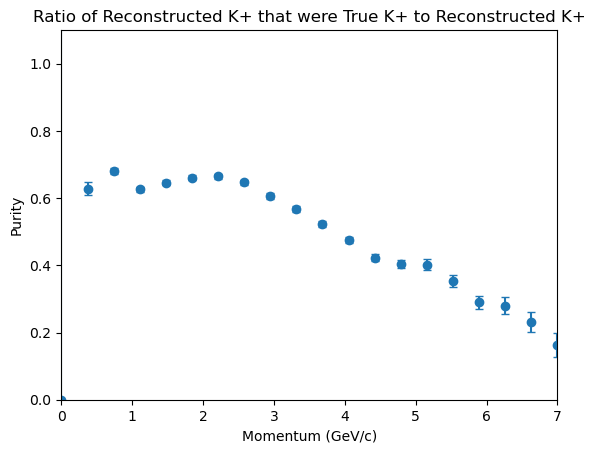

In [6]:


fig, ax = plt.subplots()

x = np.linspace(left, right, len(vals))

ax.errorbar(
    x,
    vals,
    yerr=np.array(errs),
    fmt='o',
    capsize=3
)
ax.set_ylim(0, 1.1)
ax.set_xlim(left, right)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Purity")
ax.set_title("Ratio of Reconstructed K+ that were True K+ to Reconstructed K+")
fig.savefig("figures/purityK.png", dpi=150)

plt.show()

In [7]:
p=left    #computes Mis-ID
vals =[]
errs=[]
for i in range(bins):
    pCut = matched[((matched["p"]>=p)&(matched["p"] < p+steps))]
    a= ((pCut["mc_matching_pid"]==321) & (pCut["pid"]!=321)).sum()
    b= (pCut["mc_matching_pid"]==321).sum()
    r=0
    rErr=99
    if b!=0:
        r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
    errs.append(rErr)
    vals.append(r)
    p = steps+p

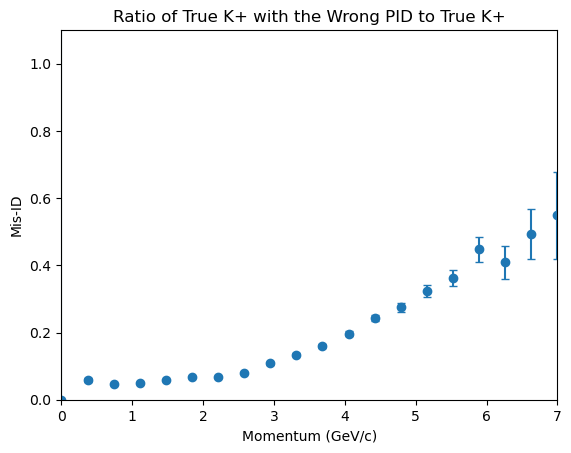

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x = np.linspace(left, right, len(vals))

ax.errorbar(
    x,
    vals,
    yerr=np.array(errs),
    fmt='o',
    capsize=3
)
ax.set_ylim(0, 1.1)
ax.set_xlim(left, right)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Mis-ID")
ax.set_title("Ratio of True K+ with the Wrong PID to True K+")
fig.savefig("figures/misIdK.png", dpi=150)
plt.show()

In [9]:
import math
p=left   #computes Comntaminiation
vals =[]
errs=[]
for i in range(bins):
    pCut = matched[((matched["p"]>=p)&(matched["p"] < p+steps))]
    a= ((pCut["mc_matching_pid"]!=321) & (pCut["pid"]==321)).sum()
    b= (pCut["pid"]==321).sum()
    r=0
    rErr=99
    if b!=0:
        r=a/b
        if a!=0:
            rErr = r*math.sqrt((1/a)+(1/b))
    errs.append(rErr)
    vals.append(r)
    p = steps+p

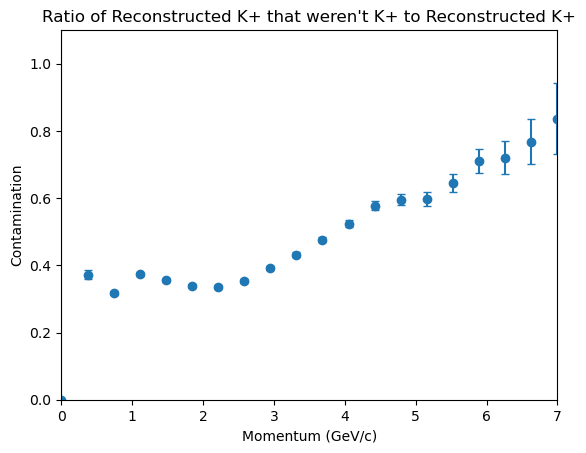

In [10]:
fig, ax = plt.subplots()

x = np.linspace(left, right, len(vals))

ax.errorbar(
    x,
    vals,
    yerr=np.array(errs),
    fmt='o',
    capsize=3
)
ax.set_ylim(0, 1.1)
ax.set_xlim(left, right)
ax.set_xlabel("Momentum (GeV/c)")
ax.set_ylabel("Contamination")
ax.set_title("Ratio of Reconstructed K+ that weren't K+ to Reconstructed K+")
fig.savefig("figures/contaminationK.png", dpi=150)

plt.show()